In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels as sm
from statsmodels.formula.api import ols
import scipy.stats as stats
from scipy.stats import mannwhitneyu


sns.set_style('whitegrid')

path = '/Users/tuckeringlefield/Desktop/Data_Science/AdvStatMethods/CaseStudies/Fish Data-1.csv'
df = pd.read_csv(path)
df.head()

,ID,Lake,Alkalinity,pH,Calcium,Chlorophyll,Avg_Mercury,No.samples,min,max,3_yr_Standard_Mercury,age_data
0,1,Alligator,5.9,6.1,3.0,0.7,1.23,5,0.85,1.43,1.53,1
1,2,Annie,3.5,5.1,1.9,3.2,1.33,7,0.92,1.90,1.33,0
2,3,Apopka,116.0,9.1,44.1,128.3,0.04,6,0.04,0.06,0.04,0
3,4,BlueCypress,39.4,6.9,16.4,3.5,0.44,12,0.13,0.84,0.44,0
4,5,Brick,2.5,4.6,2.9,1.8,1.20,12,0.69,1.50,1.33,1


## 1. Verify (or dispute) the results in the underlined statements (we see 5 statistical results). For each result, verify the conditions needed to perform the statistical analysis. Include graphs as appropriate. 

### Statement 1: 
Linear regression revealed that pH accounted for 41% of the variation in the standardized fish mercury concentration.

In [3]:
# simple linear regression model
# Y = 3_yr_Standard_Mercury
# X = pH
df = df.rename(columns={'3_yr_Standard_Mercury': 'StdMerc'})
model1 = ols("StdMerc ~ pH", data = df).fit()
print(model1.summary())


                            OLS Regression Results                            
Dep. Variable:                StdMerc   R-squared:                       0.376
Model:                            OLS   Adj. R-squared:                  0.363
Method:                 Least Squares   F-statistic:                     30.68
Date:                Mon, 22 Apr 2024   Prob (F-statistic):           1.07e-06
Time:                        20:13:23   Log-Likelihood:                -4.8437
No. Observations:                  53   AIC:                             13.69
Df Residuals:                      51   BIC:                             17.63
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.5751      0.195      8.066      0.0

In [4]:
# It looks like the r^2 isn't what they said
# lets see if they used a log transform
df['LogStdMerc'] = np.log(df['StdMerc'])
model1 = ols("LogStdMerc ~ pH", data = df)
model_sum = model1.fit()
print(model_sum.summary())

                            OLS Regression Results                            
Dep. Variable:             LogStdMerc   R-squared:                       0.440
Model:                            OLS   Adj. R-squared:                  0.429
Method:                 Least Squares   F-statistic:                     40.05
Date:                Mon, 22 Apr 2024   Prob (F-statistic):           6.24e-08
Time:                        20:13:23   Log-Likelihood:                -48.610
No. Observations:                  53   AIC:                             101.2
Df Residuals:                      51   BIC:                             105.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.8435      0.446      4.134      0.0

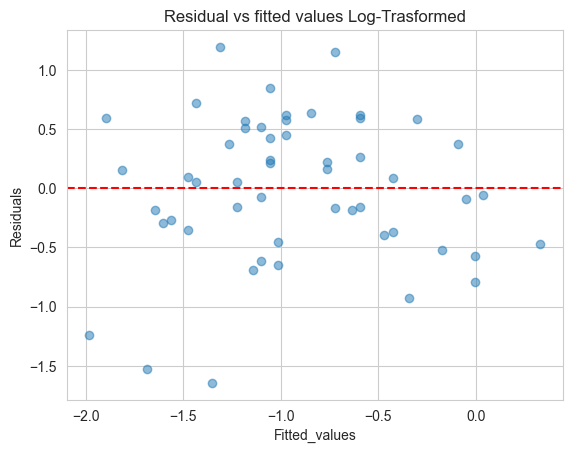

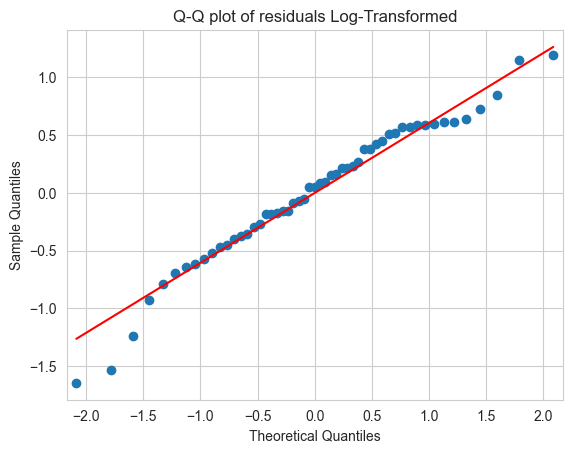

In [5]:
fitted_values = model_sum.fittedvalues
residuals = model_sum.resid
plt.scatter(fitted_values, residuals, alpha = 0.5)
plt.xlabel("Fitted_values")
plt.ylabel("Residuals")
plt.title("Residual vs fitted values Log-Trasformed")
plt.axhline(y= 0, color = 'r', linestyle = '--') # Add horizontal line at y = 0
plt.show()
import statsmodels.api as sm
sm.graphics.qqplot(residuals, line = 's', ax = plt.gca()) # 's' line for standardized line
plt.title("Q-Q plot of residuals Log-Transformed")
plt.show()

In [6]:
# this leads us closer but I'm not sure wheather to confirm or deny
# It seems like they used a log transform to get this claim

### Statement 2:
Multiple regression revealed that chlorophyll a and alkalinity accounted for 45% of the variation in the standardized fish mercury concentration.

In [7]:
# again, lets try it both ways and see...
# y = StdMerc, LogStdMerc
# x = Chlorophyll, Alkalinity
model1 = ols("StdMerc ~ Chlorophyll + Alkalinity", data = df)
model_sum = model1.fit()
print(model_sum.summary())

                            OLS Regression Results                            
Dep. Variable:                StdMerc   R-squared:                       0.450
Model:                            OLS   Adj. R-squared:                  0.428
Method:                 Least Squares   F-statistic:                     20.42
Date:                Mon, 22 Apr 2024   Prob (F-statistic):           3.29e-07
Time:                        20:13:24   Log-Likelihood:                -1.4998
No. Observations:                  53   AIC:                             9.000
Df Residuals:                      50   BIC:                             14.91
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.7476      0.051     14.698      

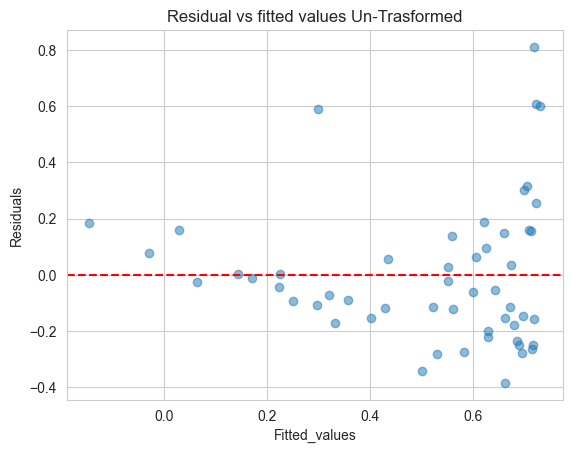

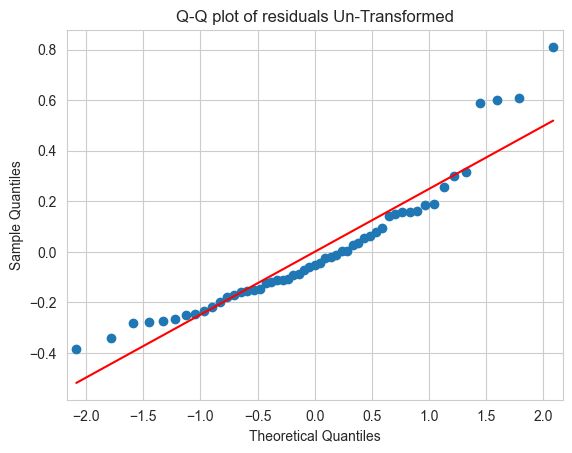

In [8]:
fitted_values = model_sum.fittedvalues
residuals = model_sum.resid
plt.scatter(fitted_values, residuals, alpha = 0.5)
plt.xlabel("Fitted_values")
plt.ylabel("Residuals")
plt.title("Residual vs fitted values Un-Trasformed")
plt.axhline(y= 0, color = 'r', linestyle = '--') # Add horizontal line at y = 0
plt.show()
import statsmodels.api as sm
sm.graphics.qqplot(residuals, line = 's', ax = plt.gca()) # 's' line for standardized line
plt.title("Q-Q plot of residuals Un-Transformed")
plt.show()

In [9]:
model1 = ols("LogStdMerc ~ Chlorophyll + Alkalinity", data = df).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:             LogStdMerc   R-squared:                       0.745
Model:                            OLS   Adj. R-squared:                  0.735
Method:                 Least Squares   F-statistic:                     72.95
Date:                Mon, 22 Apr 2024   Prob (F-statistic):           1.49e-15
Time:                        20:13:24   Log-Likelihood:                -27.782
No. Observations:                  53   AIC:                             61.56
Df Residuals:                      50   BIC:                             67.47
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -0.2207      0.084     -2.642      

In [10]:
# They used the untransformed data on this part! Weird

### Statement 3:
Mercury concentrations were significantly higher in lakes with either pH less than 7, alkalinity less than 20 mg/L as CaCO3, or chlorophyll a less than 10 μg/L.

In [11]:
# We will have to do 3 two sample t tests to verify these claims
from scipy.stats import shapiro, levene, ttest_ind, probplot

Mercury concentrations were significantly higher in lakes with pH less than 7?

In [12]:
# Set up groups of data
small_ph = pd.DataFrame()
small_ph = df[df['pH'] < 7]
large_ph = pd.DataFrame()
large_ph = df[df['pH'] >= 7]

Shaprio Large PH: ShapiroResult(statistic=0.8828331232070923, pvalue=0.013688917271792889)
Shaprio Small PH: ShapiroResult(statistic=0.9213498830795288, pvalue=0.02563999779522419)
Levene PH: LeveneResult(statistic=3.069384166651452, pvalue=0.08579087189739433)


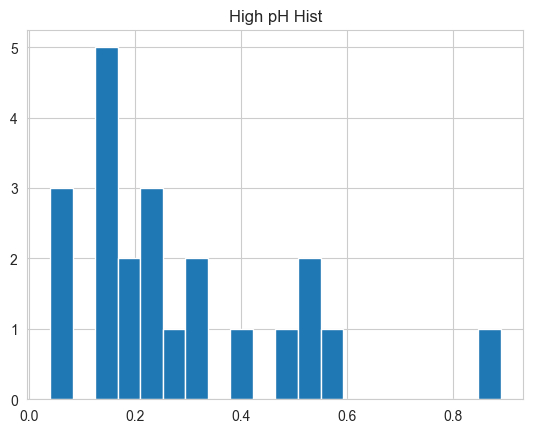

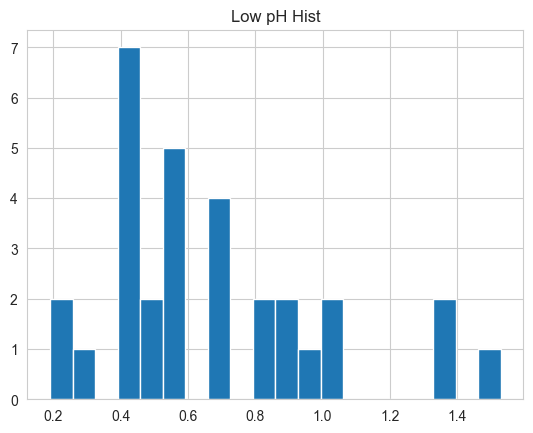

In [13]:
# Asses assumptions:
# Normality, equal variance
shapiro_large = shapiro(large_ph['StdMerc'])
shapiro_small = shapiro(small_ph['StdMerc'])
levene_res = levene(large_ph['StdMerc'], small_ph['StdMerc'])
print(f'Shaprio Large PH: {shapiro_large}')
print(f'Shaprio Small PH: {shapiro_small}')
print(f'Levene PH: {levene_res}')
plt.hist(large_ph['StdMerc'], bins = 20)
plt.title('High pH Hist')
plt.show()
plt.hist(small_ph['StdMerc'], bins = 20)
plt.title('Low pH Hist')
plt.show()

Shaprio Large PH: ShapiroResult(statistic=0.9216522574424744, pvalue=0.0822560265660286)
Shaprio Small PH: ShapiroResult(statistic=0.9745659828186035, pvalue=0.6516977548599243)
Levene PH: LeveneResult(statistic=3.6778877364100215, pvalue=0.06074675186725145)


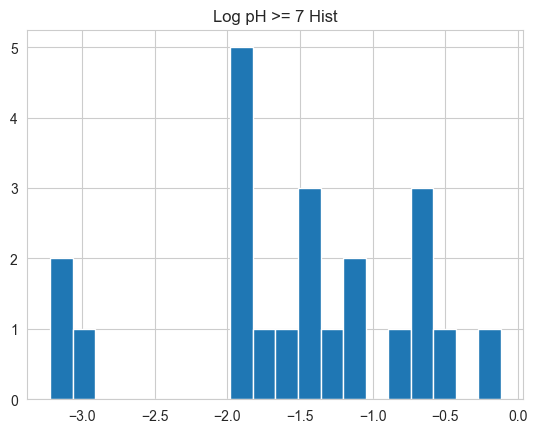

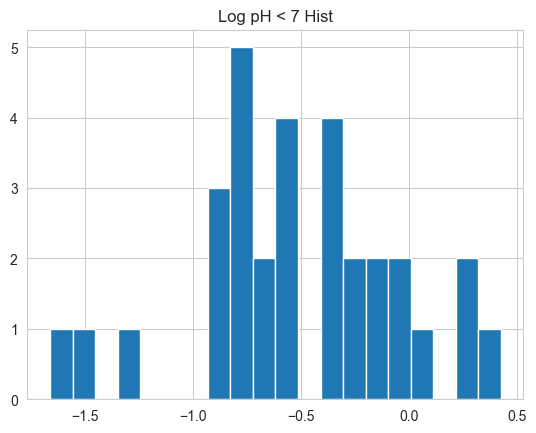

In [14]:
# Doesn't meet the assumptions, let see if a log transform would help...
shapiro_large = shapiro(large_ph['LogStdMerc'])
shapiro_small = shapiro(small_ph['LogStdMerc'])
levene_res = levene(large_ph['LogStdMerc'], small_ph['LogStdMerc'])
print(f'Shaprio Large PH: {shapiro_large}')
print(f'Shaprio Small PH: {shapiro_small}')
print(f'Levene PH: {levene_res}')
plt.hist(large_ph['LogStdMerc'], bins = 20)
plt.title('Log pH >= 7 Hist')
plt.show()
plt.hist(small_ph['LogStdMerc'], bins = 20)
plt.title('Log pH < 7 Hist')
plt.show()


In [15]:
# They probably used the log transfomed data, it improved the assumption checks

In [16]:
# perform test
res = ttest_ind(small_ph['LogStdMerc'],large_ph['LogStdMerc'], equal_var = True)
print(res)

TtestResult(statistic=5.599624834565135, pvalue=8.631521143048515e-07, df=51.0)


In [17]:
# We know that there is a significant differance
# We need to know which direction it is in 
# and if this lines up with the qustion:
avg_small_ph = sum(small_ph['StdMerc'])/len(small_ph['StdMerc'])
avg_large_ph = sum(large_ph['StdMerc'])/len(large_ph['StdMerc'])
print('Small avg(<7):')
print(avg_small_ph)
print('Large avg(>=7)')
print(avg_large_ph)

Small avg(<7):
0.6732258064516129
Large avg(>=7)
0.28772727272727266


Mercury concentrations were significantly higher in lakes with alkalinity less than 20 mg/L?

In [18]:
# Set up groups of data
low_alk = pd.DataFrame()
low_alk = df[df['Alkalinity']<20]
high_alk = pd.DataFrame()
high_alk = df[df['Alkalinity']>=20]

Shaprio High Chlorophyll: ShapiroResult(statistic=0.9075339436531067, pvalue=0.023154666647315025)
Shaprio Low Chlorophyll: ShapiroResult(statistic=0.9020921587944031, pvalue=0.014939517714083195)
Levene Chlorophyll: LeveneResult(statistic=1.8768678267189205, pvalue=0.17669193797170651)


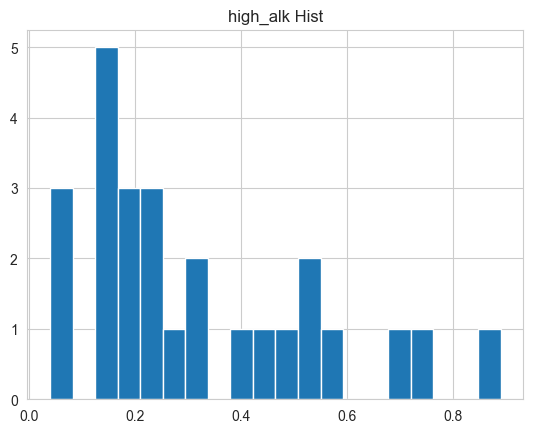

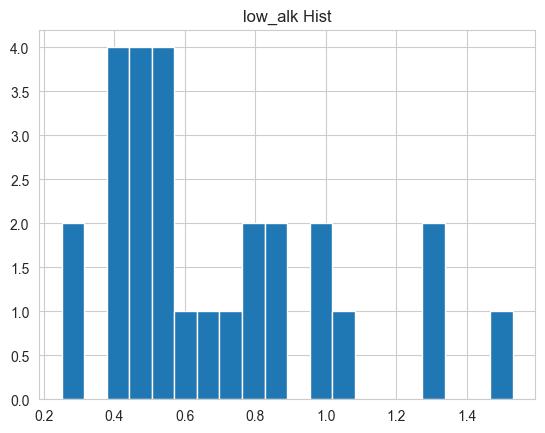

In [19]:
# Asses assumptions:
# Normality, equal variance
shapiro_large = shapiro(high_alk['StdMerc'])
shapiro_small = shapiro(low_alk['StdMerc'])
levene_res = levene(high_alk['StdMerc'], low_alk['StdMerc'])
print(f'Shaprio High Chlorophyll: {shapiro_large}')
print(f'Shaprio Low Chlorophyll: {shapiro_small}')
print(f'Levene Chlorophyll: {levene_res}')
plt.hist(high_alk['StdMerc'], bins = 20)
plt.title('high_alk Hist')
plt.show()
plt.hist(low_alk['StdMerc'], bins = 20)
plt.title('low_alk Hist')
plt.show()

Shaprio High Chlorophyll: ShapiroResult(statistic=0.9251418113708496, pvalue=0.05942070856690407)
Shaprio Low Chlorophyll: ShapiroResult(statistic=0.969548761844635, pvalue=0.5899322628974915)
Levene Chlorophyll: LeveneResult(statistic=5.170465416788476, pvalue=0.02721399686151187)


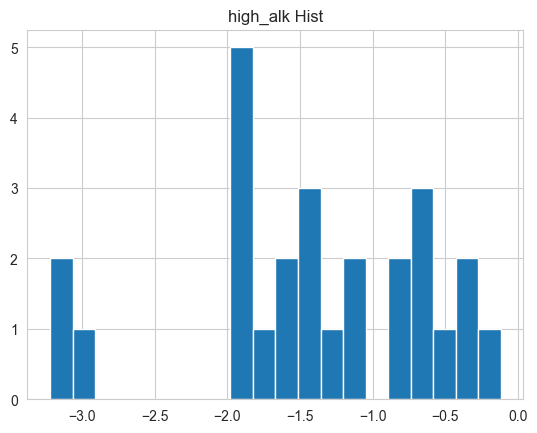

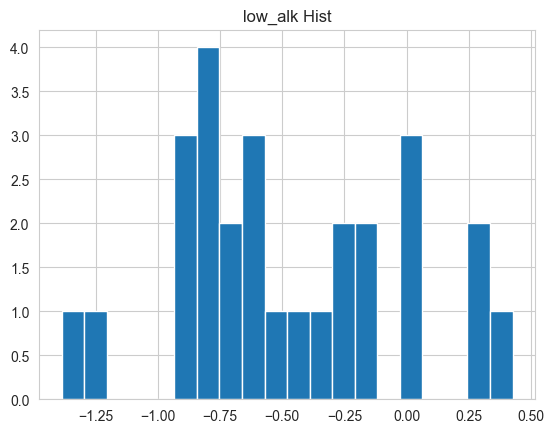

In [20]:
# Doesn't meet the assumptions, let see if a log transform would help...
shapiro_large = shapiro(high_alk['LogStdMerc'])
shapiro_small = shapiro(low_alk['LogStdMerc'])
levene_res = levene(high_alk['LogStdMerc'], low_alk['LogStdMerc'])
print(f'Shaprio High Chlorophyll: {shapiro_large}')
print(f'Shaprio Low Chlorophyll: {shapiro_small}')
print(f'Levene Chlorophyll: {levene_res}')
plt.hist(high_alk['LogStdMerc'], bins = 20)
plt.title('high_alk Hist')
plt.show()
plt.hist(low_alk['LogStdMerc'], bins = 20)
plt.title('low_alk Hist')
plt.show()

In [21]:
# We were able to get both groups to be normal but cannot get equal variance, probably a one sample t-test on the difference?
# non parametric test

In [22]:
# perform test
# T-test with unequal variance (welch)
res = ttest_ind(low_alk['LogStdMerc'],high_alk['LogStdMerc'], equal_var = False)
print(res)
res = ttest_ind(low_alk['StdMerc'],high_alk['StdMerc'], equal_var = True)
print(res)
#again let's confirm direction...
avg_small_ph = sum(low_alk['StdMerc'])/len(low_alk['StdMerc'])
avg_large_ph = sum(high_alk['StdMerc'])/len(high_alk['StdMerc'])
print('low avg(<20):')
print(avg_small_ph)
print('high avg (>=20)')
print(avg_large_ph)

TtestResult(statistic=5.0764444044729595, pvalue=1.0082786513509834e-05, df=38.5896140689268)
TtestResult(statistic=4.778134557000283, pvalue=1.5387211915848107e-05, df=51.0)
low avg(<20):
0.6962962962962964
high avg (>=20)
0.3230769230769231


Mercury concentrations were significantly higher in lakes with chlorophyll less than 10 μg/L?

In [23]:
# Set up groups of data
low_chlor = pd.DataFrame()
low_chlor = df[df['Chlorophyll'] < 10 ]
high_chlor = pd.DataFrame()
high_chlor = df[df['Chlorophyll'] >= 10 ]

Shaprio High Chlorophyll: ShapiroResult(statistic=0.9409359693527222, pvalue=0.11676285415887833)
Shaprio Low Chlorophyll: ShapiroResult(statistic=0.8998907804489136, pvalue=0.018246082589030266)
Levene Chlorophyll: LeveneResult(statistic=1.5254319558160145, pvalue=0.22245913807758774)


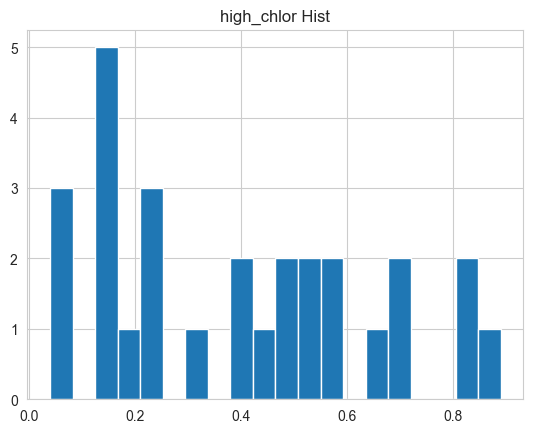

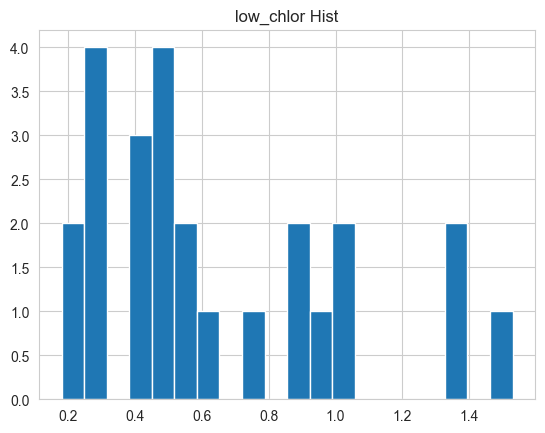

In [24]:
# Asses assumptions:
# Normality, equal variance
shapiro_large = shapiro(high_chlor['StdMerc'])
shapiro_small = shapiro(low_chlor['StdMerc'])
levene_res = levene(high_chlor['StdMerc'], low_chlor['StdMerc'])
print(f'Shaprio High Chlorophyll: {shapiro_large}')
print(f'Shaprio Low Chlorophyll: {shapiro_small}')
print(f'Levene Chlorophyll: {levene_res}')
plt.hist(high_chlor['StdMerc'], bins = 20)
plt.title('high_chlor Hist')
plt.show()
plt.hist(low_chlor['StdMerc'], bins = 20)
plt.title('low_chlor Hist')
plt.show()

Shaprio High Chlorophyll: ShapiroResult(statistic=0.888782799243927, pvalue=0.0063103907741606236)
Shaprio Low Chlorophyll: ShapiroResult(statistic=0.9656419157981873, pvalue=0.5377480387687683)
Levene Chlorophyll: LeveneResult(statistic=2.2529967390825405, pvalue=0.1395221574465901)


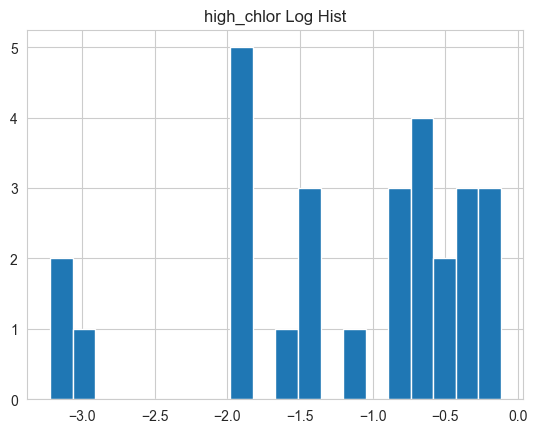

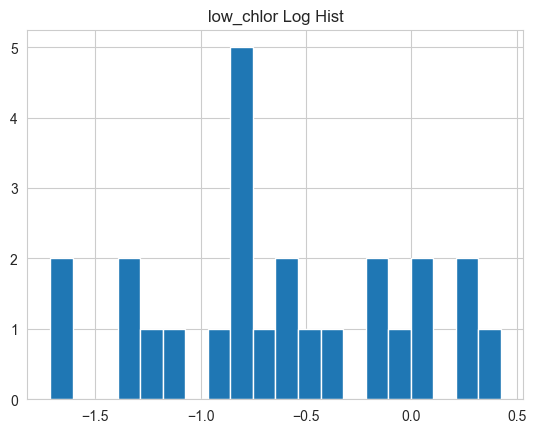

In [25]:
# Try a log transform to see if it can help normality of low Chloro group?
shapiro_large = shapiro(high_chlor['LogStdMerc'])
shapiro_small = shapiro(low_chlor['LogStdMerc'])
levene_res = levene(high_chlor['LogStdMerc'], low_chlor['LogStdMerc'])
print(f'Shaprio High Chlorophyll: {shapiro_large}')
print(f'Shaprio Low Chlorophyll: {shapiro_small}')
print(f'Levene Chlorophyll: {levene_res}')
plt.hist(high_chlor['LogStdMerc'], bins = 20)
plt.title('high_chlor Log Hist')
plt.show()
plt.hist(low_chlor['LogStdMerc'], bins = 20)
plt.title('low_chlor Log Hist')
plt.show()

In [26]:
# Interesting... Seems like we won't be able to get both groups to be normal at the same time
# non parametric test

In [27]:
# perform test
#Rank-sum test (Mann-Whitney U test) - two-sided
# untransformed
stat, p_value_two_sided = mannwhitneyu(high_chlor['StdMerc'], low_chlor['StdMerc'], use_continuity=True)
print(f'p_value = {p_value_two_sided}')
# log-transformed
stat, p_value_two_sided = mannwhitneyu(high_chlor['LogStdMerc'], low_chlor['LogStdMerc'], use_continuity=True)
print(f'p_value = {p_value_two_sided}')
#again let's confirm direction...
avg_small_ph = sum(low_chlor['StdMerc'])/len(low_chlor['StdMerc'])
avg_large_ph = sum(high_chlor['StdMerc'])/len(high_chlor['StdMerc'])
print('low avg (<10):')
print(avg_small_ph)
print('high avg(>=10)')
print(avg_large_ph)

p_value = 0.015336165441362412
p_value = 0.015336165441362412
low avg (<10):
0.6404
high avg(>=10)
0.3996428571428572


### 2. The last underlined sentence (the last sentence in the abstract) creates categories for pH, alkalinity and chlorophyll.  Run the appropriate analysis when you have 3 categorical predictor variables and want to predict a numeric response variable (standardized mercury level). Verify conditions and include appropriate graphs. 

In [28]:
# create dummy variables for these conditions?
# low_chlor (<10), low_alk (<20), low_ph (<7)
df.head()

,ID,Lake,Alkalinity,pH,Calcium,Chlorophyll,Avg_Mercury,No.samples,min,max,StdMerc,age_data,LogStdMerc
0,1,Alligator,5.9,6.1,3.0,0.7,1.23,5,0.85,1.43,1.53,1,0.425268
1,2,Annie,3.5,5.1,1.9,3.2,1.33,7,0.92,1.90,1.33,0,0.285179
2,3,Apopka,116.0,9.1,44.1,128.3,0.04,6,0.04,0.06,0.04,0,-3.218876
3,4,BlueCypress,39.4,6.9,16.4,3.5,0.44,12,0.13,0.84,0.44,0,-0.820981
4,5,Brick,2.5,4.6,2.9,1.8,1.20,12,0.69,1.50,1.33,1,0.285179


In [29]:
# Make the dummy variables
df['low_chlor'] = np.where(df['Chlorophyll'] < 10, 1, 0)
df['low_alk'] = np.where(df['Alkalinity'] < 20, 1, 0)
df['low_pH'] = np.where(df['pH'] < 7, 1, 0)
df.head()

,ID,Lake,Alkalinity,pH,Calcium,Chlorophyll,Avg_Mercury,No.samples,min,max,StdMerc,age_data,LogStdMerc,low_chlor,low_alk,low_pH
0,1,Alligator,5.9,6.1,3.0,0.7,1.23,5,0.85,1.43,1.53,1,0.425268,1,1,1
1,2,Annie,3.5,5.1,1.9,3.2,1.33,7,0.92,1.90,1.33,0,0.285179,1,1,1
2,3,Apopka,116.0,9.1,44.1,128.3,0.04,6,0.04,0.06,0.04,0,-3.218876,0,0,0
3,4,BlueCypress,39.4,6.9,16.4,3.5,0.44,12,0.13,0.84,0.44,0,-0.820981,1,0,1
4,5,Brick,2.5,4.6,2.9,1.8,1.20,12,0.69,1.50,1.33,1,0.285179,1,1,1


In [30]:
model1 = ols("StdMerc ~ low_chlor + low_alk + low_pH", data = df)
final_results = model1.fit()
print(final_results.summary())

                            OLS Regression Results                            
Dep. Variable:                StdMerc   R-squared:                       0.395
Model:                            OLS   Adj. R-squared:                  0.357
Method:                 Least Squares   F-statistic:                     10.64
Date:                Mon, 22 Apr 2024   Prob (F-statistic):           1.68e-05
Time:                        20:13:25   Log-Likelihood:                -4.0268
No. Observations:                  53   AIC:                             16.05
Df Residuals:                      49   BIC:                             23.93
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2444      0.062      3.970      0.0

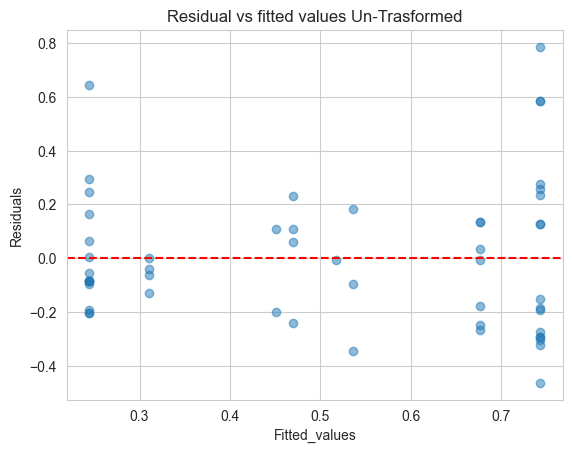

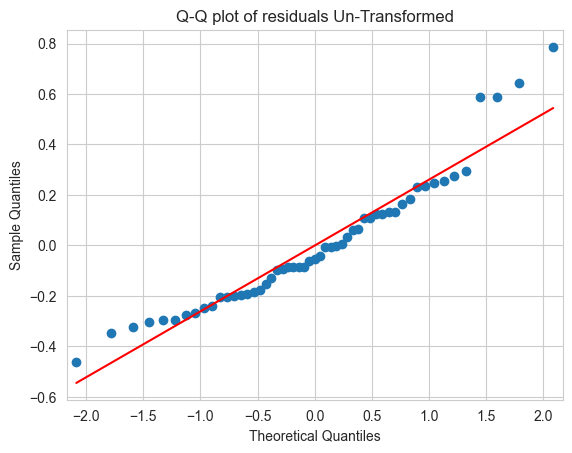

In [31]:
fitted_values = final_results.fittedvalues
residuals = final_results.resid
plt.scatter(fitted_values, residuals, alpha = 0.5)
plt.xlabel("Fitted_values")
plt.ylabel("Residuals")
plt.title("Residual vs fitted values Un-Trasformed")
plt.axhline(y= 0, color = 'r', linestyle = '--') # Add horizontal line at y = 0
plt.show()
import statsmodels.api as sm
sm.graphics.qqplot(residuals, line = 's', ax = plt.gca()) # 's' line for standardized line
plt.title("Q-Q plot of residuals Un-Transformed")
plt.show()

In [32]:
log_model = ols("LogStdMerc ~ low_chlor + low_alk + low_pH", data = df)
final_results = log_model.fit()
print(final_results.summary())

                            OLS Regression Results                            
Dep. Variable:             LogStdMerc   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.416
Method:                 Least Squares   F-statistic:                     13.33
Date:                Mon, 22 Apr 2024   Prob (F-statistic):           1.75e-06
Time:                        20:13:25   Log-Likelihood:                -48.161
No. Observations:                  53   AIC:                             104.3
Df Residuals:                      49   BIC:                             112.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.6174      0.142    -11.424      0.0

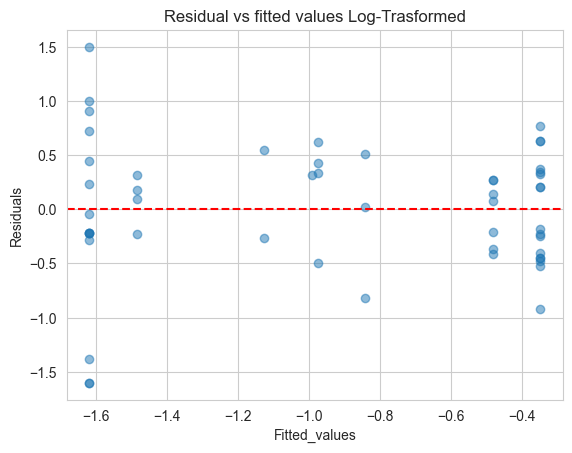

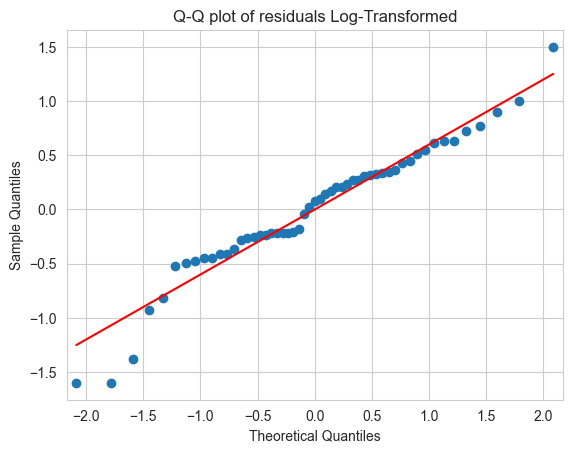

In [33]:
fitted_values = final_results.fittedvalues
residuals = final_results.resid
plt.scatter(fitted_values, residuals, alpha = 0.5)
plt.xlabel("Fitted_values")
plt.ylabel("Residuals")
plt.title("Residual vs fitted values Log-Trasformed")
plt.axhline(y= 0, color = 'r', linestyle = '--') # Add horizontal line at y = 0
plt.show()
import statsmodels.api as sm
sm.graphics.qqplot(residuals, line = 's', ax = plt.gca()) # 's' line for standardized line
plt.title("Q-Q plot of residuals Log-Transformed")
plt.show()

### 3.  The data set contains almost exclusively numeric (rather than categorical) variables.  Regression is the right technique for this scenario to predict standardized mercury levels.  The task is to build a really good model using standard linear techniques.  Make sure to consider variable transformations for both dependent and independent variables and two-way interactions as you build your model. If you include an interaction, you must include the main effect. For example, if your model includes the interaction term x1*x2, it must also include x1 and x2. Be sure to assess necessary conditions and illustrate conclusions with graphs as appropriate.

In [34]:
# Build the best model, hint: (you should know some stuff from the other questions...)

In [35]:
df.head()

,ID,Lake,Alkalinity,pH,Calcium,Chlorophyll,Avg_Mercury,No.samples,min,max,StdMerc,age_data,LogStdMerc,low_chlor,low_alk,low_pH
0,1,Alligator,5.9,6.1,3.0,0.7,1.23,5,0.85,1.43,1.53,1,0.425268,1,1,1
1,2,Annie,3.5,5.1,1.9,3.2,1.33,7,0.92,1.90,1.33,0,0.285179,1,1,1
2,3,Apopka,116.0,9.1,44.1,128.3,0.04,6,0.04,0.06,0.04,0,-3.218876,0,0,0
3,4,BlueCypress,39.4,6.9,16.4,3.5,0.44,12,0.13,0.84,0.44,0,-0.820981,1,0,1
4,5,Brick,2.5,4.6,2.9,1.8,1.20,12,0.69,1.50,1.33,1,0.285179,1,1,1


In [36]:
df.rename(columns={'No.samples': 'numSamples'}, inplace=True)

In [37]:
df.columns

Index(['ID', 'Lake', 'Alkalinity', 'pH', 'Calcium', 'Chlorophyll',
       'Avg_Mercury', 'numSamples', 'min', 'max', 'StdMerc', 'age_data',
       'LogStdMerc', 'low_chlor', 'low_alk', 'low_pH'],
      dtype='object')

In [38]:
from scipy.stats import shapiro
predictors = [ 'Alkalinity', 'pH', 'Calcium', 'Chlorophyll','numSamples', 'min', 'max', 'age_data','low_chlor', 'low_alk', 'low_pH']
for i in predictors:
    shapiro_res = shapiro(df[i])
    print(f'shapiro_res for {i} : {shapiro_res}')

shapiro_res for Alkalinity : ShapiroResult(statistic=0.8203012943267822, pvalue=1.537445314170327e-06)
shapiro_res for pH : ShapiroResult(statistic=0.9809677004814148, pvalue=0.5551718473434448)
shapiro_res for Calcium : ShapiroResult(statistic=0.7913432121276855, pvalue=3.0903962056072487e-07)
shapiro_res for Chlorophyll : ShapiroResult(statistic=0.6816633939743042, pvalue=1.9375874238392043e-09)
shapiro_res for numSamples : ShapiroResult(statistic=0.5829697847366333, pvalue=4.987578058890385e-11)
shapiro_res for min : ShapiroResult(statistic=0.8769986629486084, pvalue=5.7976623793365434e-05)
shapiro_res for max : ShapiroResult(statistic=0.9555271863937378, pvalue=0.04672031104564667)
shapiro_res for age_data : ShapiroResult(statistic=0.4773790240287781, pvalue=1.822437383294795e-12)
shapiro_res for low_chlor : ShapiroResult(statistic=0.63558030128479, pvalue=3.230564704637118e-10)
shapiro_res for low_alk : ShapiroResult(statistic=0.6366168260574341, pvalue=3.3576399993684447e-10)
sha

In [39]:
# Normal: 
# Alkalinity, Calcium, Chlorophyll, numSamples, min, max, age_data, low_chlor, low_alk, low_pH
# Non-Normal:
# pH

#Consider a log transformation for pH? This makes interpretation weirder...

In [40]:
full_model = ols("LogStdMerc ~ Alkalinity + pH + Calcium + Chlorophyll + Avg_Mercury + numSamples + min + max + age_data + low_chlor + low_alk + low_pH ", data = df)
full_results = full_model.fit()
print(full_results.summary())

                            OLS Regression Results                            
Dep. Variable:             LogStdMerc   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.947
Method:                 Least Squares   F-statistic:                     78.10
Date:                Mon, 22 Apr 2024   Prob (F-statistic):           7.59e-24
Time:                        20:13:25   Log-Likelihood:                 20.719
No. Observations:                  53   AIC:                            -15.44
Df Residuals:                      40   BIC:                             10.17
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -1.7177      0.324     -5.307      

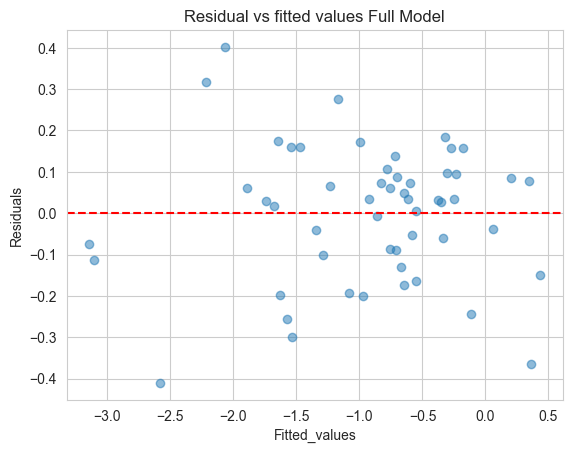

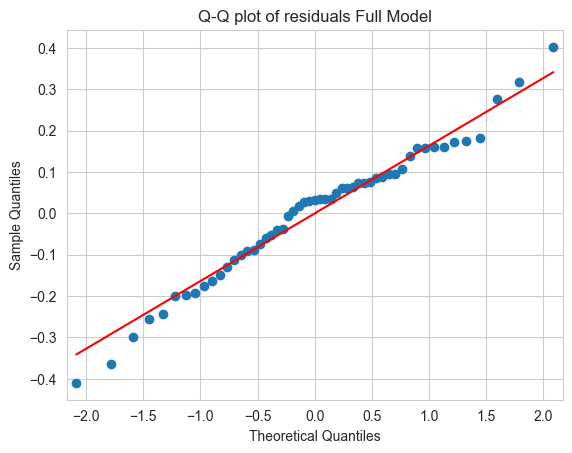

In [41]:
fitted_values = full_results.fittedvalues
residuals = full_results.resid
plt.scatter(fitted_values, residuals, alpha = 0.5)
plt.xlabel("Fitted_values")
plt.ylabel("Residuals")
plt.title("Residual vs fitted values Full Model")
plt.axhline(y= 0, color = 'r', linestyle = '--') # Add horizontal line at y = 0
plt.show()
import statsmodels.api as sm
sm.graphics.qqplot(residuals, line = 's', ax = plt.gca()) # 's' line for standardized line
plt.title("Q-Q plot of residuals Full Model")
plt.show()

In [42]:
full_results.pvalues

Intercept      4.436830e-06
Alkalinity     2.045250e-02
pH             1.516133e-01
Calcium        6.949620e-01
Chlorophyll    1.807144e-10
Avg_Mercury    1.223628e-01
numSamples     1.594201e-01
min            1.865022e-01
max            1.494958e-01
age_data       4.074965e-01
low_chlor      5.996915e-02
low_alk        6.032635e-01
low_pH         8.010875e-01
dtype: float64

In [43]:
red_model = ols("LogStdMerc ~ Alkalinity + pH + Calcium + Chlorophyll + Avg_Mercury + numSamples + min + max + age_data + low_chlor + low_alk ", data = df)
full_results = red_model.fit()
print(full_results.summary())

                            OLS Regression Results                            
Dep. Variable:             LogStdMerc   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     87.19
Date:                Mon, 22 Apr 2024   Prob (F-statistic):           8.14e-25
Time:                        20:13:26   Log-Likelihood:                 20.677
No. Observations:                  53   AIC:                            -17.35
Df Residuals:                      41   BIC:                             6.290
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -1.6813      0.287     -5.861      

In [44]:
full_results.pvalues

Intercept      6.815578e-07
Alkalinity     1.759240e-02
pH             1.434235e-01
Calcium        7.060389e-01
Chlorophyll    8.338257e-11
Avg_Mercury    1.219643e-01
numSamples     1.165081e-01
min            1.518444e-01
max            1.243651e-01
age_data       4.170178e-01
low_chlor      5.851979e-02
low_alk        5.663340e-01
dtype: float64

In [45]:
red_model = ols("LogStdMerc ~ Alkalinity + pH + Chlorophyll + Avg_Mercury + numSamples + min + max + age_data + low_chlor + low_alk ", data = df)
full_results = red_model.fit()
print(full_results.summary())

                            OLS Regression Results                            
Dep. Variable:             LogStdMerc   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     97.88
Date:                Mon, 22 Apr 2024   Prob (F-statistic):           8.56e-26
Time:                        20:13:26   Log-Likelihood:                 20.584
No. Observations:                  53   AIC:                            -19.17
Df Residuals:                      42   BIC:                             2.506
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -1.6895      0.283     -5.967      

In [46]:
full_results.pvalues

Intercept      4.428391e-07
Alkalinity     1.712202e-04
pH             1.168444e-01
Chlorophyll    3.498166e-11
Avg_Mercury    1.217139e-01
numSamples     7.651732e-02
min            1.410792e-01
max            1.279673e-01
age_data       4.529084e-01
low_chlor      6.056803e-02
low_alk        5.729500e-01
dtype: float64

In [47]:
red_model = ols("LogStdMerc ~ Alkalinity + pH + Chlorophyll + Avg_Mercury + numSamples + min + max + age_data + low_chlor ", data = df)
full_results = red_model.fit()
print(full_results.summary())

                            OLS Regression Results                            
Dep. Variable:             LogStdMerc   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.950
Method:                 Least Squares   F-statistic:                     110.5
Date:                Mon, 22 Apr 2024   Prob (F-statistic):           9.23e-27
Time:                        20:13:26   Log-Likelihood:                 20.381
No. Observations:                  53   AIC:                            -20.76
Df Residuals:                      43   BIC:                            -1.059
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -1.6104      0.245     -6.582      

In [48]:
full_results.pvalues

Intercept      5.197734e-08
Alkalinity     3.272623e-06
pH             1.364679e-01
Chlorophyll    2.408920e-11
Avg_Mercury    1.267080e-01
numSamples     8.117916e-02
min            1.212316e-01
max            1.268945e-01
age_data       4.505190e-01
low_chlor      6.577403e-02
dtype: float64

In [49]:
red_model = ols("LogStdMerc ~ Alkalinity + pH + Chlorophyll + Avg_Mercury + numSamples + min + max + low_chlor ", data = df)
full_results = red_model.fit()
print(full_results.summary())

                            OLS Regression Results                            
Dep. Variable:             LogStdMerc   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.950
Method:                 Least Squares   F-statistic:                     125.4
Date:                Mon, 22 Apr 2024   Prob (F-statistic):           1.06e-27
Time:                        20:13:26   Log-Likelihood:                 20.026
No. Observations:                  53   AIC:                            -22.05
Df Residuals:                      44   BIC:                            -4.319
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -1.6102      0.243     -6.613      

In [50]:
full_results.pvalues

Intercept      4.229372e-08
Alkalinity     1.221759e-06
pH             6.870773e-02
Chlorophyll    2.512795e-13
Avg_Mercury    1.420579e-01
numSamples     4.002515e-02
min            8.679572e-02
max            1.295145e-01
low_chlor      5.207695e-02
dtype: float64

In [51]:
red_model = ols("LogStdMerc ~ Alkalinity + pH + Chlorophyll + numSamples + min + max + low_chlor ", data = df)
full_results = red_model.fit()
print(full_results.summary())

                            OLS Regression Results                            
Dep. Variable:             LogStdMerc   R-squared:                       0.956
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     139.2
Date:                Mon, 22 Apr 2024   Prob (F-statistic):           2.54e-28
Time:                        20:13:26   Log-Likelihood:                 18.713
No. Observations:                  53   AIC:                            -21.43
Df Residuals:                      45   BIC:                            -5.663
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -1.6634      0.244     -6.813      

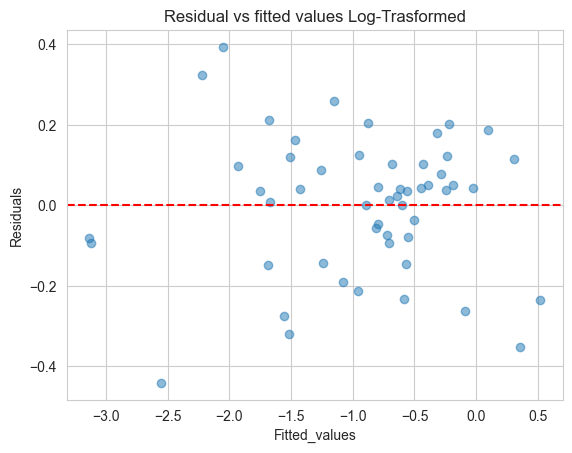

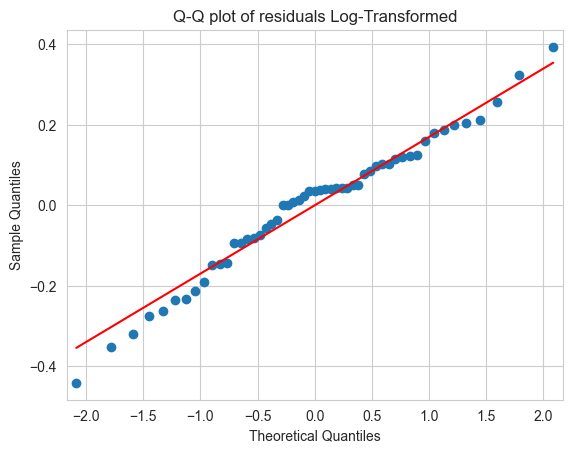

In [52]:
fitted_values = full_results.fittedvalues
residuals = full_results.resid
plt.scatter(fitted_values, residuals, alpha = 0.5)
plt.xlabel("Fitted_values")
plt.ylabel("Residuals")
plt.title("Residual vs fitted values Log-Trasformed")
plt.axhline(y= 0, color = 'r', linestyle = '--') # Add horizontal line at y = 0
plt.show()
import statsmodels.api as sm
sm.graphics.qqplot(residuals, line = 's', ax = plt.gca()) # 's' line for standardized line
plt.title("Q-Q plot of residuals Log-Transformed")
plt.show()

# Reduced model...

In [53]:
red_model = ols("LogStdMerc ~ Alkalinity + pH + Chlorophyll + numSamples + min + max ", data = df)
full_results = red_model.fit()
print(full_results.summary())

                            OLS Regression Results                            
Dep. Variable:             LogStdMerc   R-squared:                       0.953
Model:                            OLS   Adj. R-squared:                  0.947
Method:                 Least Squares   F-statistic:                     155.4
Date:                Mon, 22 Apr 2024   Prob (F-statistic):           7.94e-29
Time:                        20:13:26   Log-Likelihood:                 17.044
No. Observations:                  53   AIC:                            -20.09
Df Residuals:                      46   BIC:                            -6.296
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -1.8672      0.218     -8.583      

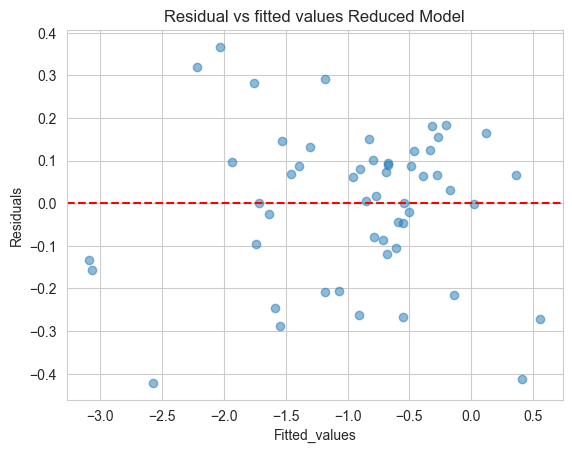

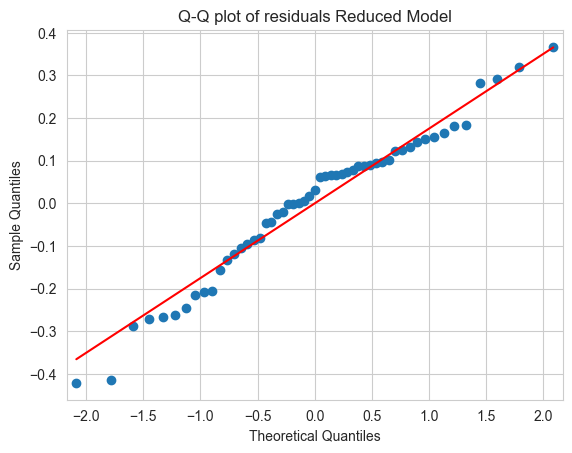

In [54]:
fitted_values = full_results.fittedvalues
residuals = full_results.resid
plt.scatter(fitted_values, residuals, alpha = 0.5)
plt.xlabel("Fitted_values")
plt.ylabel("Residuals")
plt.title("Residual vs fitted values Reduced Model")
plt.axhline(y= 0, color = 'r', linestyle = '--') # Add horizontal line at y = 0
plt.show()
import statsmodels.api as sm
sm.graphics.qqplot(residuals, line = 's', ax = plt.gca()) # 's' line for standardized line
plt.title("Q-Q plot of residuals Reduced Model")
plt.show()

In [55]:
full_model = ols("LogStdMerc ~ Alkalinity + pH + Calcium + Chlorophyll + Avg_Mercury + numSamples + min + max + age_data + low_chlor + low_alk + low_pH ", data = df)
full_results = full_model.fit()
red_model = ols("LogStdMerc ~ Alkalinity + pH + Chlorophyll + numSamples + min + max ", data = df)
red_results = red_model.fit()

In [56]:
# Use anova to compare full vs reduced model...
from statsmodels.stats.anova import anova_lm
anova_results = anova_lm(red_results, full_results)
print(anova_results)

   df_resid       ssr  df_diff   ss_diff         F    Pr(>F)
0      46.0  1.631072      0.0       NaN       NaN       NaN
1      40.0  1.419848      6.0  0.211224  0.991768  0.443968


4. Compare and contrast your results from Tasks 2 and 3 to the conclusions given by the authors in the abstract.

In [57]:
df.head()

,ID,Lake,Alkalinity,pH,Calcium,Chlorophyll,Avg_Mercury,numSamples,min,max,StdMerc,age_data,LogStdMerc,low_chlor,low_alk,low_pH
0,1,Alligator,5.9,6.1,3.0,0.7,1.23,5,0.85,1.43,1.53,1,0.425268,1,1,1
1,2,Annie,3.5,5.1,1.9,3.2,1.33,7,0.92,1.90,1.33,0,0.285179,1,1,1
2,3,Apopka,116.0,9.1,44.1,128.3,0.04,6,0.04,0.06,0.04,0,-3.218876,0,0,0
3,4,BlueCypress,39.4,6.9,16.4,3.5,0.44,12,0.13,0.84,0.44,0,-0.820981,1,0,1
4,5,Brick,2.5,4.6,2.9,1.8,1.20,12,0.69,1.50,1.33,1,0.285179,1,1,1


In [58]:
red_model = ols("LogStdMerc ~ Alkalinity + pH + Chlorophyll + numSamples + min + max ", data = df)
full_results = red_model.fit()
print(full_results.summary())

                            OLS Regression Results                            
Dep. Variable:             LogStdMerc   R-squared:                       0.953
Model:                            OLS   Adj. R-squared:                  0.947
Method:                 Least Squares   F-statistic:                     155.4
Date:                Mon, 22 Apr 2024   Prob (F-statistic):           7.94e-29
Time:                        20:13:26   Log-Likelihood:                 17.044
No. Observations:                  53   AIC:                            -20.09
Df Residuals:                      46   BIC:                            -6.296
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -1.8672      0.218     -8.583      

In [60]:
df.columns

Index(['ID', 'Lake', 'Alkalinity', 'pH', 'Calcium', 'Chlorophyll',
       'Avg_Mercury', 'numSamples', 'min', 'max', 'StdMerc', 'age_data',
       'LogStdMerc', 'low_chlor', 'low_alk', 'low_pH'],
      dtype='object')

In [64]:
# Correlation Comparison
explanatory_vars =['Alkalinity', 'pH', 'Calcium', 'Chlorophyll',
'numSamples', 'min', 'max', 'age_data', 'low_chlor', 'low_alk', 'low_pH']
for i in explanatory_vars:
    i_model = ols(f"LogStdMerc ~ {i}", data = df)
    i_results = i_model.fit()
    i_r_sq = i_results.rsquared_adj
    i_corr = np.sqrt(i_r_sq)
    print(f'{i} Corr: {i_corr}')

Alkalinity Corr: 0.7255832299487426
pH Corr: 0.6549118571749947
Calcium Corr: 0.5484101683741908
Chlorophyll Corr: 0.7456270405969193
numSamples Corr: nan
min Corr: 0.7876256500281476
max Corr: 0.8495081292264084
age_data Corr: 0.21831528323477956
low_chlor Corr: 0.3411193692001917
low_alk Corr: 0.5721391497919728
low_pH Corr: 0.6071188798545563


/var/folders/yl/0k738k9x1wn7tbbplx4xpf6c0000gn/T/ipykernel_46541/2249452708.py:8: RuntimeWarning: invalid value encountered in sqrt
  i_corr = np.sqrt(i_r_sq)
